# **Simulación Numérica de la Ecuación de Calor 2D: Tradicional con Condiciones Mixtas**
Este notebook aborda la resolución numérica de dos variantes de la ecuación de calor en dos dimensiones:
$$
T_t - 0.01(T_{xx} + T_{yy}) = 0
$$

Dónde $T = T(x,y,t)$, con $0 < x < 1$, $0 < y < 1$, $t > 0$.

**Condiciones de Frontera (CF):**
- $\frac{\partial T}{\partial x}(0, y, t) = 0$ &nbsp;&nbsp;&nbsp;&nbsp;(Neumann en $x = 0$)
- $\frac{\partial T}{\partial y}(1, y, t) = 0$ &nbsp;&nbsp;&nbsp;&nbsp;(Neumann en $y = 1$)
- $T(x, 0, t) = 20$ &nbsp;&nbsp;&nbsp;&nbsp;(Dirichlet en $y = 0$)
- $T(x, 1, t) = 50$ &nbsp;&nbsp;&nbsp;&nbsp;(Dirichlet en $y = 1$)

**Condiciones Iniciales (CI):**

Para ambas versiones se aplica:
$$
T(x, y, 0) = -50 \cos\left(\frac{\pi}{2}x\right) \cos\left(\frac{\pi}{2}y\right)
$$


**Objetivos del Estudio:**
- Comparar la evolución temporal (**solución transitoria**) de ambas ecuaciones utilizando métodos numéricos explícitos e implícitos.
- Estimar la **solución estacionaria** mediante métodos iterativos, incluyendo el uso de álgebra dispersa (**sparse**).
- Analizar la convergencia espacial y temporal de los métodos empleados.
- Visualizar la distribución de temperatura y estudiar la estabilidad numérica en función del parámetro $\lambda$.
- Comparar el comportamiento físico y numérico de la solución parabólica vs. la hiperbólica, evaluando sus implicaciones computacionales.

El trabajo incluirá además una comparación de mallados, análisis de la estabilidad numérica en función de $ \lambda $ y un enfoque en la optimización computacional usando matrices sparse.

## **Configuración Inicial.**
En este apartado se procederá a la importación de las librerías necesarias para la ejecución del taller, las cuales han sido previamente definidas en el archivo **`requirements.txt`**. Esto garantiza la compatibilidad del entorno de trabajo y permite realizar de manera eficiente el procesamiento de datos, el cálculo de métricas estadísticas y la visualización de resultados, asegurando así una correcta ejecución de los ejercicios posteriores.

In [87]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.sparse import lil_matrix, csr_matrix
from scipy.sparse.linalg import spsolve
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation, PillowWriter
from scipy.sparse import lil_matrix, csc_matrix
from scipy.sparse.linalg import spsolve


pd.set_option('display.max_colwidth', None)

## **Ecuación del Calor Tradicional.**
### **Introducción.**
**Definición del problema.** En este trabajo se resuelve numéricamente el siguiente problema de difusión de temperatura en dos dimensiones:
$$
T_{t} - 0.01(T_{xx} + T_{yy}) = 0, \quad T = T(x, y, t), \quad 0 < x < 1, \quad 0 < y < 1, \quad t > 0
$$

dónde $T$ representa la temperatura, $x$ y $y$ son las coordenadas espaciales y $t$ es el tiempo.

**Condiciones iniciales y de frontera.**
- **Condición Inicial (CI):**
$$
T(x, y, 0) = -50 \cos\left( \frac{\pi}{2} x \right) \cos\left( \frac{\pi}{2} y \right)
$$
- **Condiciones de Frontera (CF):**
    - $\frac{\partial T}{\partial x}(0, y, t) = 0$  (Neumann en $x=0$)
    - $\frac{\partial T}{\partial y}(1, y, t) = 0$  (Neumann en $x=1$)
    - $T(x, 0, t) = 20$  (Dirichlet en $y=0$)
    - $T(x, 1, t) = 50$  (Dirichlet en $y=1$)

**Parámetros físicos y de simulación.** Se trabajará sobre una región cuadrada $(x,y) \in (0,1) \times (0,1)$ durante un intervalo de tiempo $t > 0$. El coeficiente de difusión efectivo es $0.01$.

### **Solución Transitoria.**
En esta sección se resuelve la evolución temporal de la temperatura, es decir, cómo cambia $ T(x, y, t) $ con el tiempo.s

En cada método se implementará la discretización temporal y espacial, se simulará la evolución durante un intervalo de tiempo dado y se representarán los resultados.

Además, se realizará un análisis de convergencia para comprobar la estabilidad y precisión de los métodos según el mallado espacial y los parámetros de tiempo.

El objetivo es obtener la distribución de temperaturas en varios instantes $t$ y observar su evolución hacia el estado estacionario.

#### **Método Implícito.**

In [88]:
# Parámetros físicos.
alpha = 0.01
L = 1.0

# Discretización espacial.
Nx = Ny = 20 # Mallado cuadrado.
dx = L / (Nx - 1) # Espaciado entre nodos.

# Discretización temporal.
dt = 0.01 # Paso de tiempo.
T_max = 5 # Tiempo total de simulación.
Nt = int(T_max / dt) # Número de pasos de tiempo.

In [89]:
# Malla espacial.
x = np.linspace(0, L, Nx) # Vector de Nx puntos espaciados uniformemente entre 0 y L.
y = np.linspace(0, L, Ny) # Vector de Ny puntos espaciados uniformemente entre 0 y L.
X, Y = np.meshgrid(x, y) # Creación de la malla 2D: Matriz N^2.

# Condición inicial.
T = -50 * np.cos(np.pi * X / 2) * np.cos(np.pi * Y / 2) # Matriz en instante t=0.

In [90]:
# Construcción de la matriz A mediante Sparse: Esquema de 5 puntos.
def build_sparse_matrix_A(Nx, Ny, alpha, dt, dx):
    N = Nx * Ny # Número total de nodos: N^2.
    A = lil_matrix((N, N)) # Matriz dispersa vacía: Cada fila se representa como una lista de columnas con valores distintos de cero.
    lam = alpha * dt / dx**2 # Número de Fourier: lambda.
    for j in range(Ny):
        for i in range(Nx):
            idx = j * Nx + i # De 2D a 1D.
            if j == 0 or j == Ny - 1:  # Dirichlet en y=0 y y=L. Valor fijo.
                A[idx, idx] = 1
                continue
            A[idx, idx] = 1 + 4 * lam # Coeficiente de la diagonal principal.
            if i == 0: # Neumann x=0.
                A[idx, idx + 1] = -2 * lam # Reflexión simétrica.
            elif i == Nx - 1:  # Neumann x=L.
                A[idx, idx - 1] = -2 * lam # Reflexión simétrica.
            else:
                A[idx, idx - 1] = -lam # Izquierda.
                A[idx, idx + 1] = -lam # Derecha.
            A[idx, idx - Nx] = -lam # Arriba.
            A[idx, idx + Nx] = -lam # Abajo.
    return csc_matrix(A) # Convertir a formato CSR para eficiencia en la solución.

A_sparse = build_sparse_matrix_A(Nx, Ny, alpha, dt, dx)

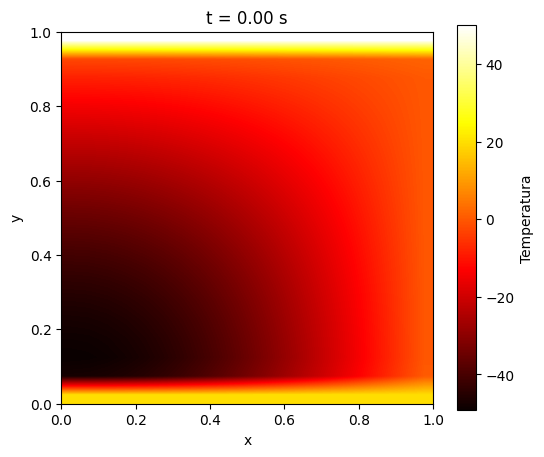

In [91]:
# Simulación y captura de frames.
frames = []
for n in range(Nt): # Iterar sobre el tiempo.
    T_flat = T.flatten() # Convertir a 1D para la matriz dispersa.
    T_flat[:Nx] = 20         # y = 0.
    T_flat[-Nx:] = 50        # y = 1.
    T_new = spsolve(A_sparse, T_flat) # A*x=b.
    T = T_new.reshape((Ny, Nx)) # Volver a 2D.
    if n % 5 == 0:           # Guardar cada 5 pasos (~100 frames totales).
        frames.append(T.copy())

# Crear animación.
fig, ax = plt.subplots(figsize=(6, 5))
cax = ax.imshow(frames[0], origin='lower', cmap='hot', extent=[0, 1, 0, 1], interpolation='bilinear')
cbar = fig.colorbar(cax, ax=ax)
cbar.set_label('Temperatura')
title = ax.set_title("t = 0.00 s")
plt.xlabel('x')
plt.ylabel('y')
plt.xlim(0, 1)
plt.ylim(0, 1)
plt.grid(False)
plt.show()

In [92]:
def update(frame_idx):
    cax.set_data(frames[frame_idx])
    t_val = frame_idx * 5 * dt
    title.set_text(f"t = {t_val:.2f} s")
    return cax, title

anim = FuncAnimation(fig, update, frames=len(frames), interval=100)
anim.save("../figures/informe-02/transitoria_sparse.gif", writer=PillowWriter(fps=10))

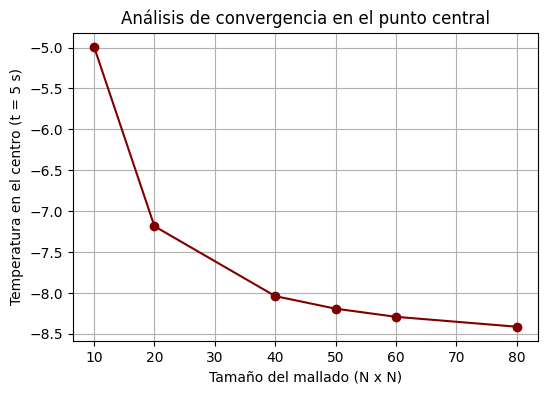

In [94]:
# Mallas a comparar.
mallas = [10, 20, 40, 50, 60, 80]
tiempo_central = []

# Simulación para cada malla.
for N in mallas:
    dx = L / (N - 1)
    x = np.linspace(0, L, N)
    y = np.linspace(0, L, N)
    X, Y = np.meshgrid(x, y)
    ix_c = N // 2
    iy_c = N // 2
    A_sparse = build_sparse_matrix_A(N, N, alpha, dt, dx)
    T = -50 * np.cos(np.pi * X / 2) * np.cos(np.pi * Y / 2)

    for n in range(Nt):
        T_flat = T.flatten()
        T_flat[:N] = 20        # Dirichlet en y=0
        T_flat[-N:] = 50       # Dirichlet en y=1
        T_new = spsolve(A_sparse, T_flat)
        T = T_new.reshape((N, N))

    # Guardar temperatura central al final.
    tiempo_central.append(T[iy_c, ix_c])

# Gráfico de convergencia
plt.figure(figsize=(6, 4))
plt.plot(mallas, tiempo_central, marker='o', color='maroon')
plt.xlabel('Tamaño del mallado (N x N)')
plt.ylabel('Temperatura en el centro (t = 5 s)')
plt.title('Análisis de convergencia en el punto central')
plt.grid(True)
plt.show()

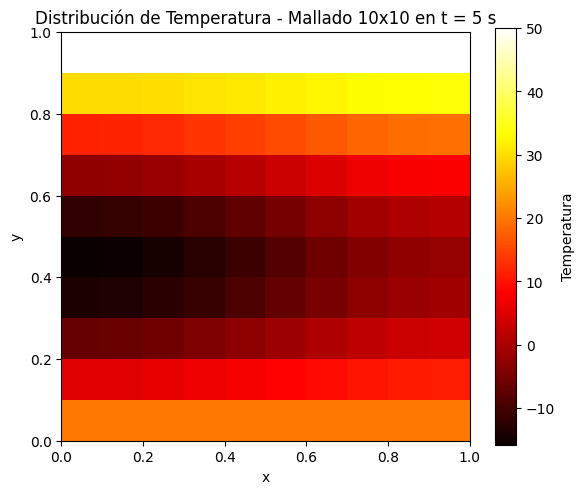

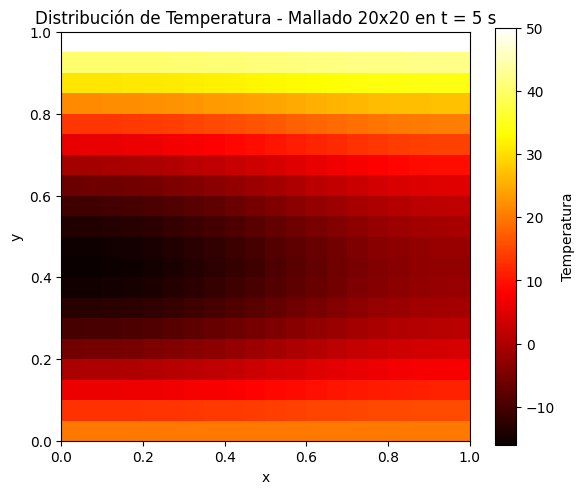

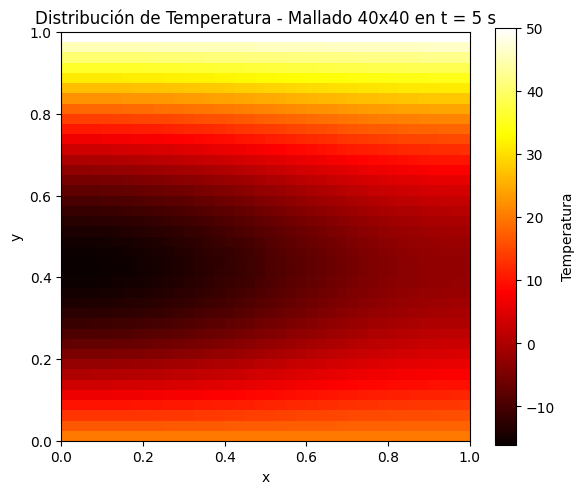

In [95]:
# Resoluciones espaciales.
resoluciones = [10, 20, 40]

# Generar mapas de calor para cada resolución.
for N in resoluciones:
    dx = L / (N - 1)
    x = np.linspace(0, L, N)
    y = np.linspace(0, L, N)
    X, Y = np.meshgrid(x, y)
    A_sparse = build_sparse_matrix_A(N, N, alpha, dt, dx)

    # Condición inicial.
    T = -50 * np.cos(np.pi * X / 2) * np.cos(np.pi * Y / 2)

    for n in range(Nt):
        T_flat = T.flatten()
        T_flat[:N] = 20       # Dirichlet en y = 0.
        T_flat[-N:] = 50      # Dirichlet en y = 1.
        T_new = spsolve(A_sparse, T_flat)
        T = T_new.reshape((N, N))

    # Graficar resultado.
    plt.figure(figsize=(6, 5))
    plt.imshow(T, origin='lower', cmap='hot', extent=[0, 1, 0, 1])
    plt.colorbar(label='Temperatura')
    plt.title(f'Distribución de Temperatura - Mallado {N}x{N} en t = 5 s')
    plt.xlabel('x')
    plt.ylabel('y')
    plt.tight_layout()
    plt.show()

### **Solución Estacionaria.**

Una vez alcanzado un tiempo suficientemente grande, la temperatura $ T(x, y, t) $ tiende a una solución que ya no varía con el tiempo, denominada solución estacionaria.

En esta sección se resolverá directamente el problema estacionario, es decir, se buscará $ T(x, y) $ tal que:

$$
0 = 0.01(T_{xx} + T_{yy})
$$

para las condiciones de frontera dadas.

Se mostrarán las soluciones obtenidas para distintos tamaños de malla, comparando la eficiencia y precisión de los métodos.

#### **Método Implícito con Matrices Sparse (código propio).**

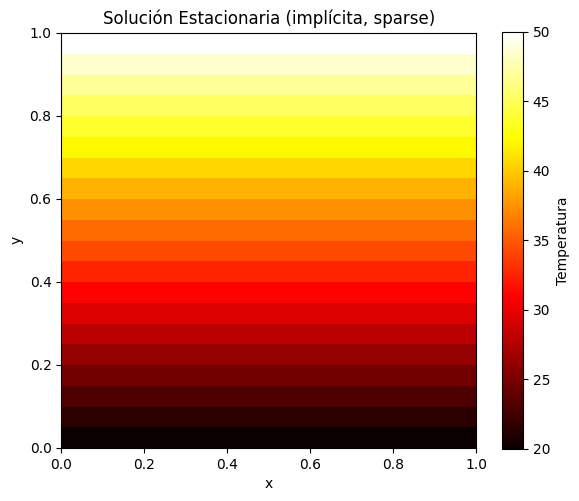

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.sparse import lil_matrix, csc_matrix
from scipy.sparse.linalg import spsolve

# Parámetros físicos
L = 1.0
Nx = Ny = 20
dx = L / (Nx - 1)
N = Nx * Ny

# Condiciones de contorno
T_abajo = 20
T_arriba = 50

# Construir matriz A y vector b
A = lil_matrix((N, N))
b = np.zeros(N)

for j in range(Ny):
    for i in range(Nx):
        idx = j * Nx + i  # índice lineal

        if j == 0:  # Dirichlet en y = 0
            A[idx, idx] = 1
            b[idx] = T_abajo
        elif j == Ny - 1:  # Dirichlet en y = L
            A[idx, idx] = 1
            b[idx] = T_arriba
        else:
            A[idx, idx] = -4
            # Neumann en x = 0
            if i == 0:
                A[idx, idx + 1] = 2
            # Neumann en x = L
            elif i == Nx - 1:
                A[idx, idx - 1] = 2
            else:
                A[idx, idx - 1] = 1
                A[idx, idx + 1] = 1

            A[idx, idx - Nx] = 1  # abajo
            A[idx, idx + Nx] = 1  # arriba

# Convertir a formato comprimido y resolver
A_sparse = csc_matrix(A)
T_flat = spsolve(A_sparse, b)
T = T_flat.reshape((Ny, Nx))

# Visualización
plt.figure(figsize=(6, 5))
plt.imshow(T, origin='lower', cmap='hot', extent=[0, 1, 0, 1])
plt.colorbar(label="Temperatura")
plt.title("Solución Estacionaria (implícita, sparse)")
plt.xlabel("x")
plt.ylabel("y")
plt.tight_layout()
plt.show()

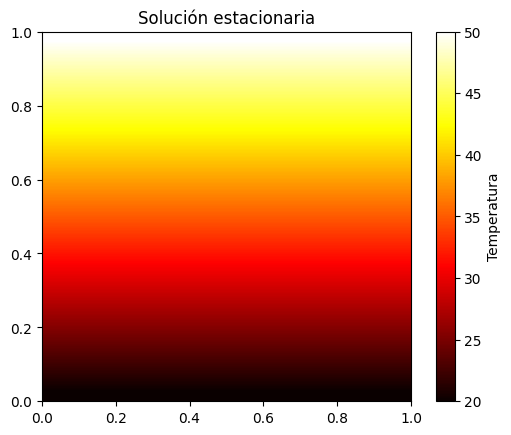

In [100]:
import numpy as np
import matplotlib.pyplot as plt

# Parámetros
L = 1.0
Nx = Ny = 20  # Tamaño pequeño para prueba manual
dx = L / (Nx - 1)
N = Nx * Ny

# Condiciones de contorno
T_abajo = 20
T_arriba = 50
b = np.zeros(N)

data = []
indices = []
indptr = [0]

for j in range(Ny):
    for i in range(Nx):
        idx = j * Nx + i
        row_data = []
        row_indices = []

        if j == 0:
            row_data.append(1)
            row_indices.append(idx)
            b[idx] = T_abajo

        elif j == Ny - 1:
            row_data.append(1)
            row_indices.append(idx)
            b[idx] = T_arriba

        else:
            # Diagonal central
            row_data.append(-4)
            row_indices.append(idx)

            if i == 0:
                row_data.append(2)
                row_indices.append(idx + 1)
            elif i == Nx - 1:
                row_data.append(2)
                row_indices.append(idx - 1)
            else:
                row_data += [1, 1]
                row_indices += [idx - 1, idx + 1]

            row_data += [1, 1]
            row_indices += [idx - Nx, idx + Nx]

        # Añadir a CSR
        data.extend(row_data)
        indices.extend(row_indices)
        indptr.append(len(data))

def gauss_seidel_csr(data, indices, indptr, b, tol=1e-5, max_iter=10000):
    N = len(b)
    x = np.zeros_like(b)

    for _ in range(max_iter):
        x_old = x.copy()
        for i in range(N):
            row_start = indptr[i]
            row_end = indptr[i + 1]
            sum_ = 0
            diag = 0
            for k in range(row_start, row_end):
                col = indices[k]
                val = data[k]
                if col == i:
                    diag = val
                else:
                    sum_ += val * x[col]
            x[i] = (b[i] - sum_) / diag
        if np.linalg.norm(x - x_old, ord=np.inf) < tol:
            break
    return x



T_flat = gauss_seidel_csr(data, indices, indptr, b)
T = T_flat.reshape((Ny, Nx))


plt.imshow(T, origin='lower', cmap='hot', extent=[0, 1, 0, 1], interpolation='bilinear')
plt.colorbar(label='Temperatura')
plt.title("Solución estacionaria")
plt.savefig("../figures/informe-02/estacionaria_sparse.png", dpi=300)
plt.show()